C:\Users\deepa\AppData\Local\Temp\ipykernel_17324\1252598177.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


--- 🚨 THE TRUE 3-COUNTRY BREAKDOWN 🚨 ---
region
India          37341
South Korea     1161
Japan            697
Name: count, dtype: int64


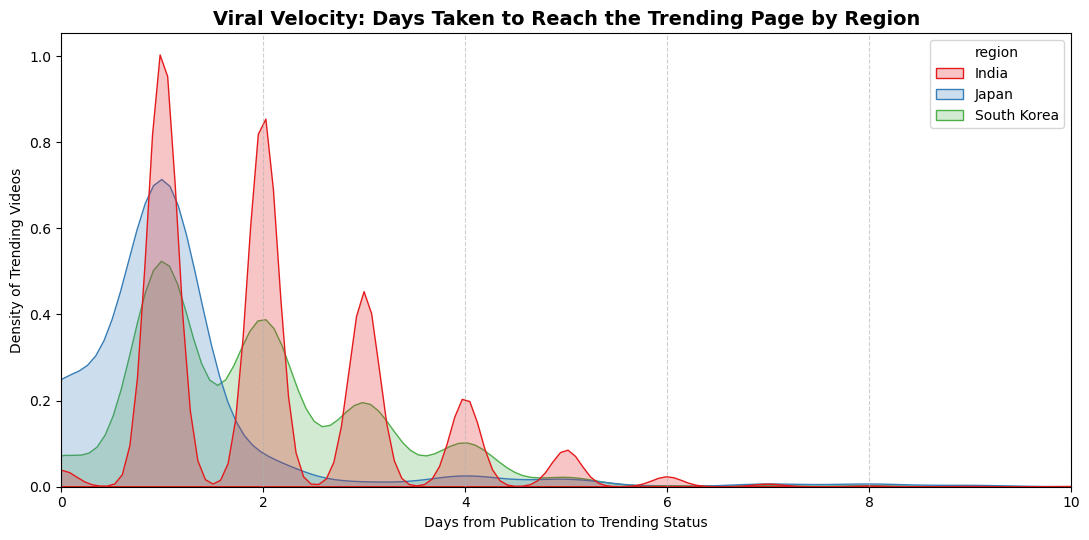

In [4]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

connection_string = (
    "Driver={SQL Server};"
    "Server=localhost\SQLEXPRESS;"
    "Database=yt_analytics;"
    "Trusted_Connection=yes;"
)
conn = pyodbc.connect(connection_string)

# Pull the fresh records straight from the updated 3-way view
query = """
SELECT 
    video_id, region, views, likes,
    CAST(trending_date AS DATE) AS trending_date, 
    CAST(publish_time AS DATE) AS publish_date
FROM view_cleaned_youtube_master;
"""

df = pd.read_sql(query, conn)
conn.close()

# Native datetime conversions and gap calculations
df['trending_date'] = pd.to_datetime(df['trending_date'])
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['days_to_trend'] = (df['trending_date'] - df['publish_date']).dt.days

# Keep the standard 0-14 days viral velocity window
df_plots = df[(df['days_to_trend'] >= 0) & (df['days_to_trend'] <= 14)].copy()

print("--- 🚨 THE TRUE 3-COUNTRY BREAKDOWN 🚨 ---")
print(df_plots['region'].value_counts())
print("=========================================")

# Render all three distributions together
if not df_plots.empty:
    plt.figure(figsize=(11, 5.5))
    sns.kdeplot(
        data=df_plots, 
        x='days_to_trend', 
        hue='region', 
        fill=True, 
        common_norm=False, 
        palette='Set1',
        bw_adjust=1.0
    )
    plt.title('Viral Velocity: Days Taken to Reach the Trending Page by Region', fontsize=14, fontweight='bold')
    plt.xlabel('Days from Publication to Trending Status')
    plt.ylabel('Density of Trending Videos')
    plt.xlim(0, 10)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

C:\Users\deepa\AppData\Local\Temp\ipykernel_17324\2950989195.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plots, x='region', y='engagement_rate', palette='Set2', width=0.4, showfliers=False)
C:\Users\deepa\AppData\Local\Temp\ipykernel_17324\2950989195.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plots, x='region', y='engagement_rate', palette='Set2', alpha=0.4, inner=None)


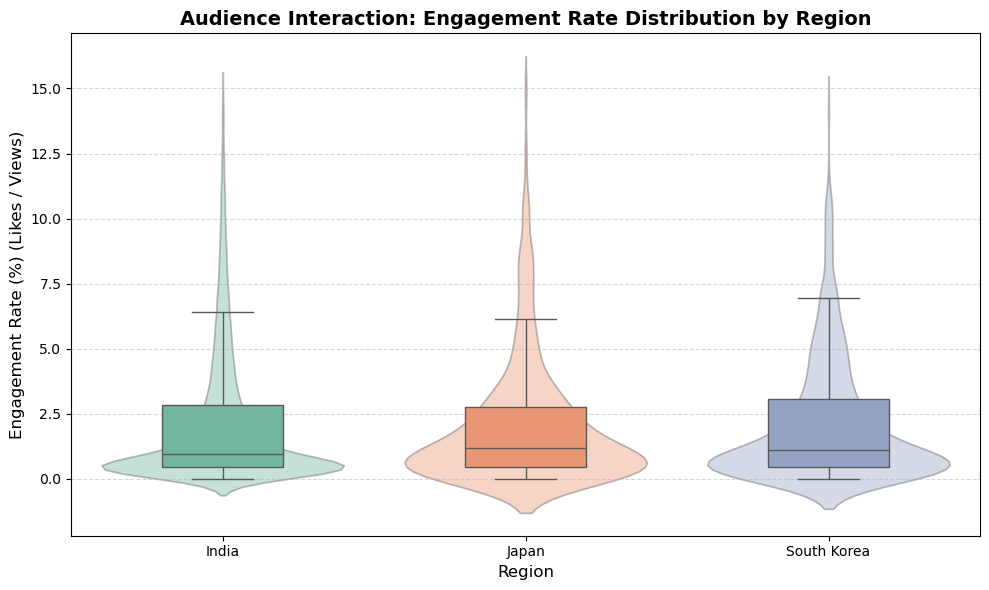

--- 📊 ENGAGEMENT RATE STATISTICAL SUMMARY ---
                 mean       50%
region                         
India        2.126138  0.943818
Japan        2.052388  1.160549
South Korea  2.091531  1.102347


In [5]:
# 1. Compute Engagement Rate using the dataframe (df) already sitting in your memory
df_clean = df[(df['days_to_trend'] >= 0) & (df['days_to_trend'] <= 14)].copy()
df_clean['engagement_rate'] = (df_clean['likes'] / df_clean['views']) * 100

# Remove anomalies to keep the visual clean
df_clean = df_clean.dropna(subset=['engagement_rate'])
df_plots = df_clean[(df_clean['engagement_rate'] <= 15) & (~df_clean['engagement_rate'].isin([np.inf, -np.inf]))].copy()

# 2. Render the Comparative Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plots, x='region', y='engagement_rate', palette='Set2', width=0.4, showfliers=False)
sns.violinplot(data=df_plots, x='region', y='engagement_rate', palette='Set2', alpha=0.4, inner=None)

plt.title('Audience Interaction: Engagement Rate Distribution by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Engagement Rate (%) (Likes / Views)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- 📊 ENGAGEMENT RATE STATISTICAL SUMMARY ---")
print(df_plots.groupby('region')['engagement_rate'].describe()[['mean', '50%']])

C:\Users\deepa\AppData\Local\Temp\ipykernel_17324\657260603.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_categories = pd.read_sql(query, conn)


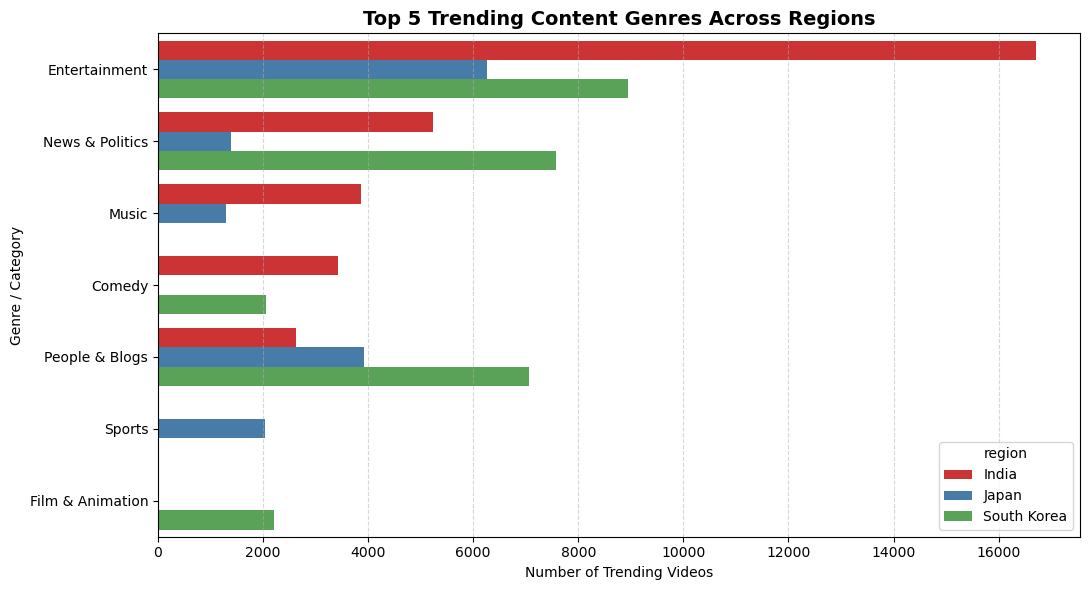

--- 🎭 REGIONAL TOP GENRES MATRIX ---
     region       genre_name  video_count
      India    Entertainment        16712
      India  News & Politics         5241
      India            Music         3858
      India           Comedy         3429
      India   People & Blogs         2624
      Japan    Entertainment         6259
      Japan   People & Blogs         3915
      Japan           Sports         2037
      Japan  News & Politics         1392
      Japan            Music         1290
South Korea    Entertainment         8955
South Korea  News & Politics         7582
South Korea   People & Blogs         7056
South Korea Film & Animation         2200
South Korea           Comedy         2056


In [7]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab a quick connection to pull the category ID
connection_string = (
    "Driver={SQL Server};"
    "Server=localhost\SQLEXPRESS;"
    "Database=yt_analytics;"
    "Trusted_Connection=yes;"
)
conn = pyodbc.connect(connection_string)

# We include 'category_id' in our SELECT list this time!
query = """
SELECT region, category_id
FROM view_cleaned_youtube_master;
"""
df_categories = pd.read_sql(query, conn)
conn.close()

# 2. Map standard YouTube Category IDs to actual names so the chart is easy to read
# (Since the view stores category_id as numeric codes)
category_map = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals',
    17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming',
    21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment',
    25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology',
    29: 'Nonprofits & Activism', 30: 'Movies', 31: 'Anime/Animation', 32: 'Action/Adventure',
    33: 'Classics', 34: 'Comedy', 35: 'Documentary', 36: 'Drama', 37: 'Family',
    38: 'Foreign', 39: 'Horror', 40: 'Sci-Fi/Fantasy', 41: 'Thriller', 42: 'Shorts',
    43: 'Shows', 44: 'Trailers'
}

# Apply the mapping to create a readable category name column
df_categories['genre_name'] = df_categories['category_id'].map(category_map).fillna('Other')

# 3. Group by region and genre to find the most popular categories
df_genres = df_categories.groupby(['region', 'genre_name']).size().reset_index(name='video_count')

# Get the top 5 trending genres for each region
df_top_genres = df_genres.sort_values(['region', 'video_count'], ascending=[True, False]).groupby('region').head(5)

# 4. Create a clean grouped bar chart
plt.figure(figsize=(11, 6))
sns.barplot(
    data=df_top_genres, 
    x='video_count', 
    y='genre_name', 
    hue='region', 
    palette='Set1'
)

plt.title('Top 5 Trending Content Genres Across Regions', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trending Videos')
plt.ylabel('Genre / Category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- 🎭 REGIONAL TOP GENRES MATRIX ---")
print(df_top_genres.to_string(index=False))

C:\Users\deepa\AppData\Local\Temp\ipykernel_17324\1654405163.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dislikes = pd.read_sql(query_step3, conn)


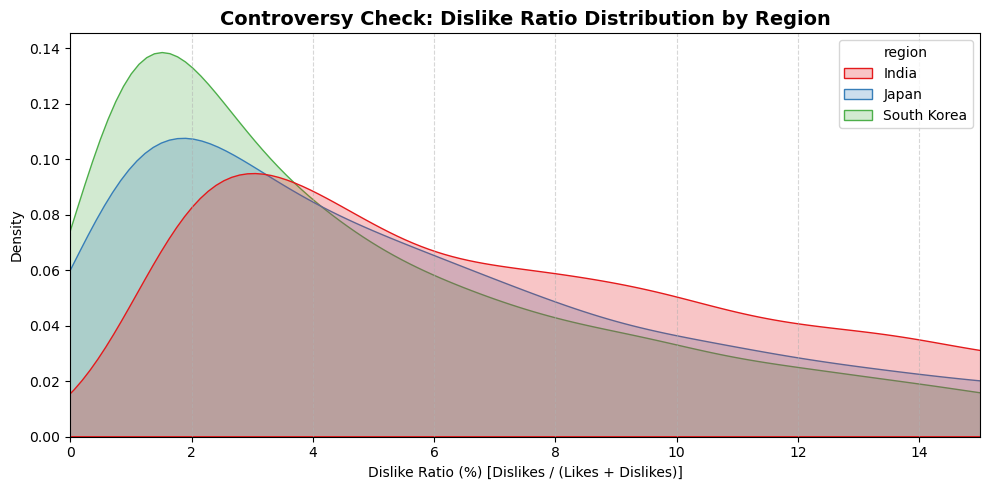

--- 📉 AVERAGE DISLIKE RATIO PER REGION ---
region
India          7.905410
Japan          6.191677
South Korea    5.330844
Name: dislike_ratio, dtype: float64


In [8]:
# 1. Pull dynamic fields for step 3 from database safely
import pyodbc
conn = pyodbc.connect("Driver={SQL Server};Server=localhost\SQLEXPRESS;Database=yt_analytics;Trusted_Connection=yes;")

query_step3 = """
SELECT region, likes, dislikes 
FROM view_cleaned_youtube_master 
WHERE likes > 0 OR dislikes > 0;
"""
df_dislikes = pd.read_sql(query_step3, conn)
conn.close()

# 2. Calculate Dislike Ratio
df_dislikes['dislike_ratio'] = (df_dislikes['dislikes'] / (df_dislikes['likes'] + df_dislikes['dislikes'])) * 100

# Filter out extreme anomalies to focus on the main distributions
df_dislikes_clean = df_dislikes[df_dislikes['dislike_ratio'] <= 20].copy()

# 3. Plot distribution curves
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_dislikes_clean, x='dislike_ratio', hue='region', fill=True, common_norm=False, palette='Set1', bw_adjust=1.5)
plt.title('Controversy Check: Dislike Ratio Distribution by Region', fontsize=14, fontweight='bold')
plt.xlabel('Dislike Ratio (%) [Dislikes / (Likes + Dislikes)]')
plt.ylabel('Density')
plt.xlim(0, 15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- 📉 AVERAGE DISLIKE RATIO PER REGION ---")
print(df_dislikes_clean.groupby('region')['dislike_ratio'].mean())

C:\Users\deepa\AppData\Local\Temp\ipykernel_17324\382574340.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_hours = pd.read_sql(query_step4, conn)


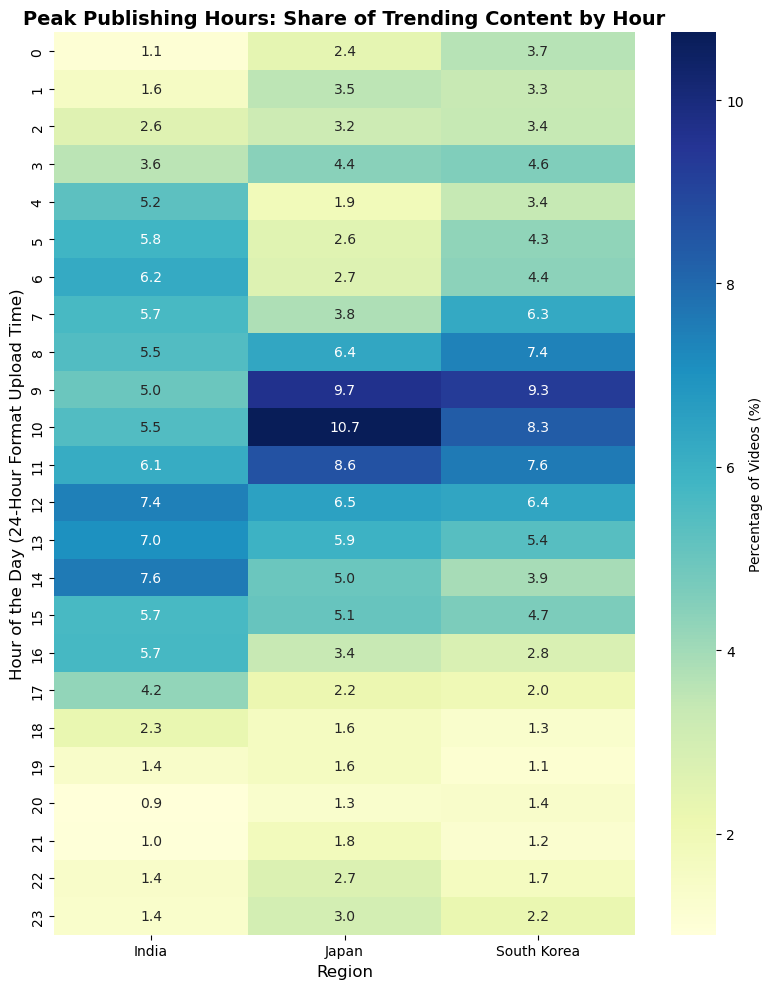

In [9]:
# 1. Fetch publish timestamps
conn = pyodbc.connect("Driver={SQL Server};Server=localhost\SQLEXPRESS;Database=yt_analytics;Trusted_Connection=yes;")
query_step4 = "SELECT region, CAST(publish_time AS VARCHAR(50)) AS pub_str FROM view_cleaned_youtube_master;"
df_hours = pd.read_sql(query_step4, conn)
conn.close()

# 2. Extract hour component cleanly
df_hours['publish_time'] = pd.to_datetime(df_hours['pub_str'], errors='coerce')
df_hours = df_hours.dropna(subset=['publish_time'])
df_hours['publish_hour'] = df_hours['publish_time'].dt.hour

# 3. Pivot the data to build a distribution profile matrix
pivot_hours = pd.crosstab(df_hours['publish_hour'], df_hours['region'], normalize='columns') * 100

# 4. Render Heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(pivot_hours, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage of Videos (%)'})
plt.title('Peak Publishing Hours: Share of Trending Content by Hour', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Hour of the Day (24-Hour Format Upload Time)', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
from scipy import stats

# 1. Prepare clean data arrays for Engagement Rate testing
india_eng = df_plots[df_plots['region'] == 'India']['engagement_rate']
japan_eng = df_plots[df_plots['region'] == 'Japan']['engagement_rate']
korea_eng = df_plots[df_plots['region'] == 'South Korea']['engagement_rate']

print("=========================================================")
print("🧪 TESTING HYPOTHESIS 1: REGIONAL ENGAGEMENT RATES")
print("=========================================================")
stat_eng, p_eng = stats.kruskal(india_eng, japan_eng, korea_eng)
print(f"Kruskal-Wallis H-Statistic: {stat_eng:.4f}")
print(f"Calculated p-value: {p_eng}")

if p_eng < 0.05:
    print("🏆 RESULT: Reject Null Hypothesis! True engagement differences are statistically significant.")
else:
    print("❌ RESULT: Fail to Reject Null Hypothesis. Differences could be random noise.")

# 2. Prepare clean data arrays for Controversy / Dislike Ratio testing
india_dis = df_dislikes_clean[df_dislikes_clean['region'] == 'India']['dislike_ratio']
japan_dis = df_dislikes_clean[df_dislikes_clean['region'] == 'Japan']['dislike_ratio']
korea_dis = df_dislikes_clean[df_dislikes_clean['region'] == 'South Korea']['dislike_ratio']

print("\n=========================================================")
print("🧪 TESTING HYPOTHESIS 2: REGIONAL CONTROVERSY / DISLIKE RATIOS")
print("=========================================================")
stat_dis, p_dis = stats.kruskal(india_dis, japan_dis, korea_dis)
print(f"Kruskal-Wallis H-Statistic: {stat_dis:.4f}")
print(f"Calculated p-value: {p_dis}")

if p_dis < 0.05:
    print("🏆 RESULT: Reject Null Hypothesis! Cultural regions dictate distinct behavioral friction.")
else:
    print("❌ RESULT: Fail to Reject Null Hypothesis.")

🧪 TESTING HYPOTHESIS 1: REGIONAL ENGAGEMENT RATES
Kruskal-Wallis H-Statistic: 0.8102
Calculated p-value: 0.6669179867476822
❌ RESULT: Fail to Reject Null Hypothesis. Differences could be random noise.

🧪 TESTING HYPOTHESIS 2: REGIONAL CONTROVERSY / DISLIKE RATIOS
Kruskal-Wallis H-Statistic: 4886.8838
Calculated p-value: 0.0
🏆 RESULT: Reject Null Hypothesis! Cultural regions dictate distinct behavioral friction.
